# 聚类算法

## 基于原型（划分）聚类
- K-Means
- K-Mediods
- GMM（高斯混合模型）

## 基于层次聚类
- AGNES（自底向上聚合）
- BIRCH（平衡迭代归约聚类）
- CURE（使用代表点聚类）

## 基于密度聚类
- DBSCAN（基于密度的空间聚类）
- OPTICS（排序点识别聚类结构）

## 基于图论聚类
- 谱聚类

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
# 解决坐标轴刻度负号乱码
plt.rcParams['axes.unicode_minus'] = False
# 解决中文乱码问题
plt.rcParams['font.sans-serif'] = ['Simhei']

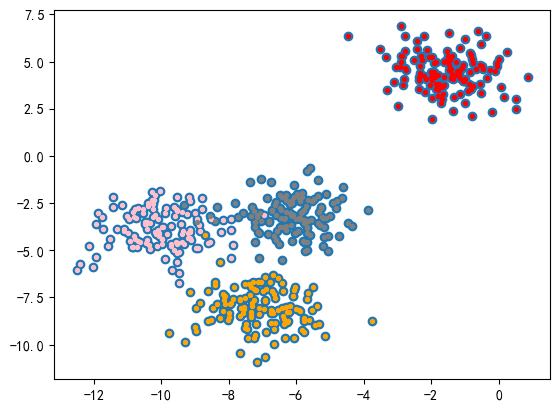

In [15]:
from sklearn.datasets import make_blobs

#自己创建数据集
X, y = make_blobs(n_samples=500,n_features=2,centers=4,random_state=1)
plt.scatter(X[:, 0], X[:, 1], marker='o')#点的形状 ,s=8 #点的大小

#查看分布
color = ["red","pink","orange","gray"]
for i in range(4):
    plt.scatter(
        # boolean索引
        X[y==i, 0], 
        X[y==i, 1],
        marker='o', #点的形状
        s=8, #点的大小
        c=color[i]
)

In [19]:
from pyclust import KMedoids
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [21]:
data1 = np.random.normal(0,0.9,(1000,10))
data2 = np.random.normal(1,0.9,(1000,10))
data3 = np.random.normal(2,0.9,(1000,10))
data4 = np.random.normal(3,0.9,(1000,10))
data5 = np.random.normal(50,0.9,(50,10))
data = np.concatenate((data1,data2,data3,data4,data5))
data.shape

(4050, 10)

In [22]:
data_TSNE = TSNE(learning_rate=100).fit_transform(data)
data_TSNE.shape

(4050, 2)

<Figure size 1200x800 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'K-medoids Resul of ')

<Axes: >

Text(0.5, 1.0, 'K-medoids Resul of ')

<Axes: >

Text(0.5, 1.0, 'K-medoids Resul of ')

<Axes: >

Text(0.5, 1.0, 'K-medoids Resul of ')

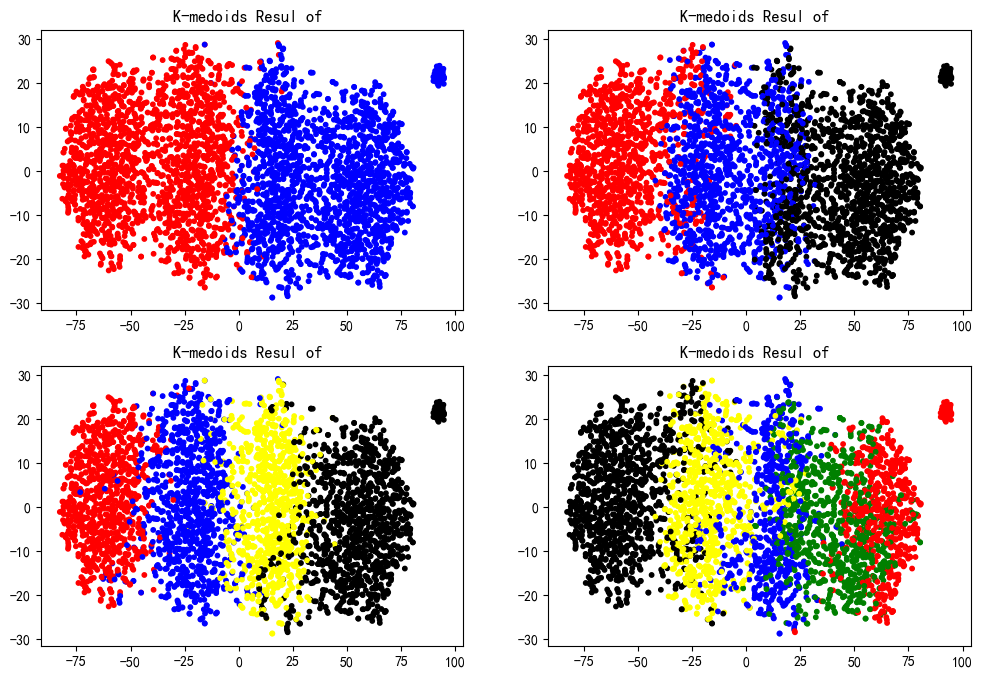

In [23]:
plt.figure(figsize=(12,8))
for i in range(2,6):
    k = KMedoids(n_clusters=i,distance='euclidean',max_iter=1000).fit_predict(data)
    colors = ([['red','blue','black','yellow','green'][i] for i in k])
    plt.subplot(219+i)
    plt.scatter(data_TSNE[:,0],data_TSNE[:,1],c=colors,s=10)
    plt.title('K-medoids Resul of '.format(str(i)))

,"n_components n_components: int, default=1The number of mixture components.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None


Text(0.5, 0, 'Feature 1')

Text(0, 0.5, 'Feature 2')

Text(0.5, 1.0, 'GMM Clustering')

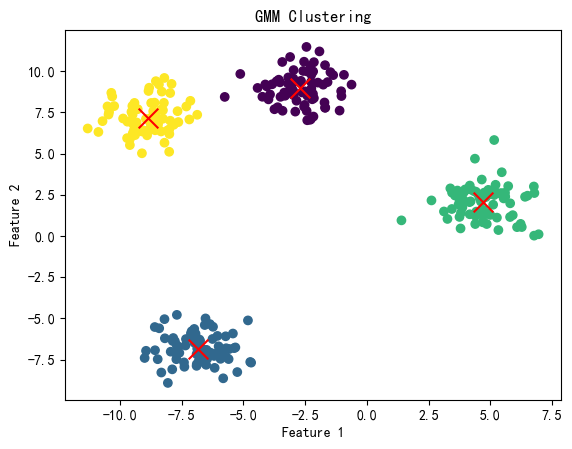

In [24]:
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# 创建一个样本数据集
X, y = make_blobs(n_samples=300, centers=4, random_state=42)

# 创建并拟合 GMM 模型
gmm = GaussianMixture(n_components=4, random_state=42)
gmm.fit(X)

# 获取聚类结果
labels = gmm.predict(X)

# 可视化聚类结果
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1], marker='x', c='red', s=200)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('GMM Clustering')
plt.show()